# Vector Autoregression (VAR)
Name: Dhairya Dhamani

# Imports, configuration, and warning handling

This cell handles the initial setup by importing all core libraries, configuring typing and abstract base classes for clean model design, and silencing harmless statsmodels warnings related to date frequency. By centralizing these imports and global configurations, the notebook remains easy to scan, avoids redundant imports in later cells, and ensures consistent, reproducible behavior. This organization is particularly vital for time-series analysis, where it prevents frequent warnings from cluttering the output and obscuring key results.

Key things to understand:

\__future__.annotations:
Allows clean type hints like list[str] without forward-reference issues.

ValueWarning suppression:
This avoids noise from statsmodels when working with irregular or reindexed
time series — you are handling frequency correctly later, so this is safe.

In [1]:
# ============================================================
# Core imports and global configuration
# ============================================================

from __future__ import annotations  # enables modern type hints like list[str]

from pathlib import Path
import warnings
import pickle

import numpy as np
import pandas as pd

from abc import ABC, abstractmethod
from typing import Dict, Tuple, Optional

from statsmodels.tsa.api import VAR
from statsmodels.tools.sm_exceptions import ValueWarning


# ============================================================
# Silence known, non-critical statsmodels warnings
# ============================================================
# statsmodels often warns about missing or inferred date frequencies.
# In this project, we explicitly control the time index ourselves,
# so these warnings are safe to ignore.
warnings.simplefilter("ignore", ValueWarning)

# Base forecasting model interface
In this cell, I define a base forecasting model interface using an abstract base class. The goal here is not to implement a model yet, but to enforce a consistent structure across any forecasting model I might use later (e.g., VAR, AR, or even a machine-learning model).

By doing this, I make sure every model has the same core methods (fit, evaluate, save, load). This keeps the pipeline clean, makes comparisons fair, and avoids ad-hoc modeling code scattered throughout the notebook. Even though this might feel like overkill for a single VAR, it mirrors how forecasting systems are built in research and production settings.

In [2]:
# ============================================================
# Base Forecast Model Interface
# ============================================================

class BaseForecastModel(ABC):
    """
    Abstract base class for forecasting models.

    Defining this interface ensures that every model in the project
    follows the same structure, making the pipeline easier to reason
    about and extend.
    """

    def __init__(self, task_type: str):
        # Task type is informational (e.g., regression, classification)
        self.task_type = task_type

    @abstractmethod
    def fit(self, *args, **kwargs):
        """
        Fit the model to training data.
        """
        pass

    @abstractmethod
    def evaluate(self, *args, **kwargs):
        """
        Evaluate the model on out-of-sample data.
        """
        pass

    @abstractmethod
    def save(self, filepath: str):
        """
        Persist the model to disk.
        """
        pass

    @abstractmethod
    def load(self, filepath: str):
        """
        Load a previously saved model from disk.
        """
        pass


# Evaluation metrics

In this cell, I define the evaluation metrics I use throughout the project. Since I’m working with daily financial returns, traditional accuracy metrics alone aren’t sufficient. I want to measure not just error magnitude, but also directional correctness, which is often more meaningful in financial forecasting.

All metrics are written to be:

- numerically safe (handle empty inputs),
- consistent across train/validation/test,
- easy to reuse in walk-forward evaluation.

I keep these as standalone functions so they can be reused cleanly without coupling them to a specific model class.

**Why these metrics together matter**

For daily oil returns:
- R² is expected to be low or negative, so it’s not the main success criterion.
- RMSE / MAE capture scale and stability of errors.
- Directional accuracy captures whether the model extracts economically useful signal.

Using all four together prevents misleading conclusions from any single metric.

In [3]:
# ============================================================
# Evaluation Metrics
# ============================================================

def rmse(y, yhat):
    """
    Root Mean Squared Error.
    Measures average magnitude of forecast errors.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2))) if len(y) else np.nan


def mae(y, yhat):
    """
    Mean Absolute Error.
    Less sensitive to large outliers than RMSE.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.abs(y - yhat))) if len(y) else np.nan


def r2(y, yhat):
    """
    Coefficient of determination.
    For daily returns this can be negative, which is expected.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)

    if len(y) == 0:
        return np.nan

    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)

    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def directional_accuracy(y, yhat):
    """
    Fraction of times the model correctly predicts the sign
    of the return. This is especially relevant for trading-style
    interpretations.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.sign(y) == np.sign(yhat))) if len(y) else np.nan


# Data loading and preprocessing
In this cell, I define all the data helper functions used to load, align, and transform the macroeconomic and price data. The guiding principle throughout this section is strict leakage prevention. Since I’m working with macro variables and daily asset prices, it’s very easy to accidentally allow future information to leak into the past if the timing assumptions aren’t handled carefully.

These helpers make all timing assumptions explicit and reusable, so that the rest of the notebook can focus on modeling rather than data hygiene.

**Key ideas**

The most important design choice here is the monthly-to-daily conversion. By shifting monthly macro data forward by one month before forward-filling, I ensure that the model never sees information before it would realistically be available. This prevents a very common form of look-ahead bias in macro-finance work.

I also deliberately keep price alignment and return computation separate, so that timing assumptions are clear and easy to audit.

In [4]:
# ============================================================
# Data Helpers (Leakage-Safe)
# ============================================================

def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    """
    Load monthly macroeconomic data and keep only the requested features.

    The input file follows the FRED-MD format, which includes a metadata
    row that needs to be skipped.
    """
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()

    # Keep only macro variables that actually exist in the file
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]

    if missing:
        print(f"[WARN] Missing macro columns in file (skipping): {missing}")

    return df[keep].copy()


def monthly_to_daily_strict(df: pd.DataFrame, daily_freq: str = "B") -> pd.DataFrame:
    """
    Convert monthly macro data to a daily series in a leakage-safe way.

    Data observed in month m is assumed to become available at the
    beginning of month m+1. Values are then forward-filled onto a
    daily grid.

    daily_freq:
        - "B": business days (recommended for trading data)
        - "D": calendar days (only if explicitly required)
    """
    df = df.copy()

    # Shift macro data forward to reflect real-world release timing
    df.index = df.index + pd.offsets.MonthBegin(1)

    # Create a strict daily index and forward-fill values
    daily_idx = pd.date_range(df.index.min(), df.index.max(), freq=daily_freq)
    out = df.reindex(daily_idx).ffill()

    return out.dropna()


def load_price(path: Path) -> pd.Series:
    """
    Load daily price data and return a clean, sorted price series.
    """
    px = pd.read_csv(path, parse_dates=["Date"])
    s = px.set_index("Date")["Price"].sort_index()
    return s


def daily_log_return(price: pd.Series) -> pd.Series:
    """
    Compute daily log returns from a price series.
    """
    s = np.log(price.astype(float)).diff()
    return s.rename("ret_1d")


# Building the VAR data frame and time-based splits

In this cell, I combine the macroeconomic data and the oil price data into a single, aligned data frame that is suitable for VAR modeling. This is where all the earlier helper functions come together.

The key objective here is to create a dataset that:

- respects real-world data availability,
- aligns macro variables and returns on the same daily grid,
- and is split into train, validation, and test sets strictly by time.

I explicitly avoid forcing a frequency on the index. Instead, I construct the daily index myself and reindex onto it. This prevents subtle bugs and avoids misleading statsmodels warnings.

**Key details**

This part is where most time-series mistakes usually happen, so I’m deliberately explicit:

- Returns are computed after alignment, not before.
- Macro data is forward-filled only after enforcing realistic release timing.
- All splits are purely chronological, which is mandatory for forecasting.

By the time this function returns, the data is clean, aligned, and safe to use in a VAR without worrying about leakage or misinterpretation.

In [5]:
# ============================================================
# Build VAR Frame (macro + returns, leakage-safe)
# ============================================================

def build_var_frame(
    macro_file: Path,
    price_file: Path,
    macro_features: list[str],
    train_end: str,
    val_end: str,
    daily_freq: str = "B",   # "B" = business days, "D" = calendar days
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Construct the final VAR-ready data frame and split it into
    train, validation, and test sets using date cutoffs.
    """

    # --- Load and process macro data ---
    macro_m = load_macro_monthly(macro_file, macro_features)
    macro_d = monthly_to_daily_strict(macro_m, daily_freq=daily_freq)

    # --- Load and align price data ---
    price = load_price(price_file)

    # Create a common daily index shared by macro and price data
    daily_idx = pd.date_range(
        start=max(macro_d.index.min(), price.index.min()),
        end=min(macro_d.index.max(), price.index.max()),
        freq=daily_freq,
    )

    # Align prices first, then compute returns (no return fabrication)
    price = price.reindex(daily_idx).ffill()
    ret = daily_log_return(price)

    # --- Combine macro variables and returns ---
    base = macro_d.reindex(daily_idx).join(ret, how="inner")

    # Strict rule: never invent returns
    base = base.dropna(subset=["ret_1d"]).copy()
    base = base.sort_index()

    # --- Time-based splits ---
    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train_mask = base.index <= train_end
    val_mask = (base.index > train_end) & (base.index <= val_end)
    test_mask = base.index > val_end

    return (
        base.loc[train_mask],
        base.loc[val_mask],
        base.loc[test_mask],
    )


# Walk-forward VAR evaluation (true out-of-sample scoring)

In this cell, I implement the evaluation routine that actually matters for forecasting: walk-forward (expanding window) evaluation. The idea is that at each time step in the evaluation period, I only fit the VAR using data that would have been available up to that point, forecast the next step, and then move forward by one day.

This is slower than fitting once and forecasting the whole period, but it’s much more realistic and protects me from accidentally overstating performance. I also include a min_train_obs guard so the model doesn’t start forecasting until it has enough observations to fit sensibly.

**Why this evaluation is the “right” one**

This avoids the most common pitfall in time-series modeling: fitting once on all training data and forecasting the whole future horizon without refitting. Walk-forward evaluation forces the model to behave the way it would in a real forecasting setup, where new data arrives over time and the model is updated repeatedly.

In [6]:
# ============================================================
# Walk-Forward VAR Evaluation (1-step ahead)
# ============================================================

def walk_forward_var_score(
    df_train: pd.DataFrame,
    df_eval: pd.DataFrame,
    target_col: str,
    best_lag: int,
    min_train_obs: int = 500,
) -> Dict:
    """
    Expanding-window walk-forward evaluation.

    For each date in df_eval:
      1) Fit VAR on all data available so far (history)
      2) Forecast one step ahead
      3) Score only the target column (e.g., daily returns)

    This produces a true out-of-sample evaluation that mirrors
    how forecasting would work in practice.
    """

    if target_col not in df_train.columns:
        raise ValueError(f"target_col={target_col} not in df_train columns")

    history = df_train.copy()
    y_true, y_pred = [], []

    for i in range(len(df_eval)):

        # Don’t forecast until we have enough training history
        if len(history) < min_train_obs:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        try:
            # Fit VAR on expanding history
            model = VAR(history).fit(best_lag)

            # Forecast next step using the last `best_lag` observations
            fc = model.forecast(history.values[-best_lag:], steps=1)[0]

            # Extract prediction corresponding to target_col
            pred = fc[history.columns.get_loc(target_col)]
        except Exception:
            # If fitting fails for numerical reasons, just move on safely
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        # Store the true value and the prediction
        y_true.append(df_eval.iloc[i][target_col])
        y_pred.append(pred)

        # Expand history with the newly observed row
        history = pd.concat([history, df_eval.iloc[[i]]])

    # Convert to arrays for metric computation
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "best_lag": int(best_lag),
        "n_scored": int(len(y_true)),
        "rmse": rmse(y_true, y_pred),
        "mae": mae(y_true, y_pred),
        "r2": r2(y_true, y_pred),
        "directional_acc": directional_accuracy(y_true, y_pred),
    }


# Greedy forward feature selection using BIC

In this cell, I implement a greedy forward feature selection procedure tailored specifically for VAR models. The goal here is to select a small, interpretable set of macro variables that improves out-of-sample behavior without overfitting or creating an unstable system.

I use BIC as the selection criterion because VARs scale quadratically in the number of variables, and BIC penalizes model complexity more aggressively than AIC. I also impose a hard cap on the number of features to prevent collinearity and numerical instability, which are very real concerns in high-dimensional VARs.
Why this selection strategy is appropriate

VARs become unstable very quickly as the number of variables grows. By combining:

- BIC (to penalize complexity),
- a small lag grid,
- and a strict feature cap,

I ensure that the final system remains interpretable, numerically stable, and suitable for out-of-sample forecasting. The history output also lets me inspect how the model evolved, which is useful for diagnostics and plotting later.

In [7]:
# ============================================================
# Greedy Forward Feature Selection (BIC + hard cap)
# ============================================================

def greedy_var_feature_select(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    macro_candidates: list[str],
    target_col: str = "ret_1d",
    maxlags_grid: list[int] = [1, 2, 3, 5],
    max_features: int = 5,
    patience: int = 2,
) -> Dict:
    """
    Greedy forward feature selection for VAR models.

    Features are added one at a time based on BIC improvements
    computed on the training set. The process stops when:
      - no improvement is found for `patience` rounds, or
      - max_features is reached.
    """

    # Keep only macro candidates that exist and have usable data
    remaining = []
    for c in macro_candidates:
        if c in df_train.columns and c in df_val.columns:
            if df_train[c].notna().any() and df_val[c].notna().any():
                remaining.append(c)

    selected: list[str] = []
    history: list[dict] = []
    best_bic = np.inf
    no_improve = 0

    def bic_for_features(features: list[str]) -> Dict[str, float]:
        """
        Compute the best BIC across a grid of lags
        for a given set of features.
        """
        cols = [target_col] + features
        best = np.inf
        best_lag = None

        for lag in maxlags_grid:
            try:
                m = VAR(df_train[cols]).fit(lag)
                if np.isfinite(m.bic) and m.bic < best:
                    best = m.bic
                    best_lag = lag
            except Exception:
                continue

        return {
            "bic": best,
            "lag": best_lag if best_lag is not None else maxlags_grid[0],
        }

    # --------------------------------------------------------
    # Step 1: choose the best single macro feature
    # --------------------------------------------------------
    best_feat = None
    best_res = None

    for f in remaining:
        res = bic_for_features([f])
        if np.isfinite(res["bic"]) and res["bic"] < best_bic:
            best_bic = res["bic"]
            best_feat = f
            best_res = res

    if best_feat is None:
        return {
            "selected_features": [],
            "best_val_bic": np.nan,
            "history": history,
            "message": (
                "No feature produced a valid VAR fit. "
                "Try fewer lags or fewer candidate variables."
            ),
        }

    selected.append(best_feat)
    remaining.remove(best_feat)
    history.append({
        "added": best_feat,
        "score": best_res,
        "selected_now": selected.copy(),
    })

    # --------------------------------------------------------
    # Step 2: forward selection with early stopping
    # --------------------------------------------------------
    while remaining and len(selected) < max_features:
        round_best_feat = None
        round_best_res = None
        round_best_bic = best_bic

        for f in remaining:
            res = bic_for_features(selected + [f])
            if np.isfinite(res["bic"]) and res["bic"] < round_best_bic:
                round_best_bic = res["bic"]
                round_best_feat = f
                round_best_res = res

        if round_best_feat is None:
            no_improve += 1
            if no_improve >= patience:
                break
            continue

        # Accept the improvement
        best_bic = round_best_bic
        selected.append(round_best_feat)
        remaining.remove(round_best_feat)
        history.append({
            "added": round_best_feat,
            "score": round_best_res,
            "selected_now": selected.copy(),
        })
        no_improve = 0

    return {
        "selected_features": selected,
        "best_val_bic": float(best_bic) if np.isfinite(best_bic) else np.nan,
        "history": history,
    }


# Final VAR model wrapper (fit, evaluate, save, load)

In this cell, I implement the final model wrapper for my VAR approach. The reason I wrap the VAR in a class is so I can treat it like a “real” forecasting model with a clean API: I can fit it, evaluate it, and save/load it without rewriting plumbing each time.

The key modeling choices here are: I pick the lag using BIC over a small lag grid on the dataset I’m fitting on (in my workflow, that’s train+validation for the final model), and I evaluate performance using the walk-forward function I defined earlier so the evaluation stays realistic.

In [8]:
# ============================================================
# Final VAR Forecast Model
# ============================================================

class VARForecastModel(BaseForecastModel):
    """
    VAR forecasting model wrapper that:
      - selects lag using BIC over a grid
      - evaluates using expanding-window walk-forward forecasting
      - supports save/load via pickle
    """

    def __init__(self, maxlags_grid: list[int] = [1, 2, 3, 5], target_col: str = "ret_1d"):
        super().__init__("regression")
        self.maxlags_grid = maxlags_grid
        self.target_col = target_col

        # Learned during fitting
        self.selected_features_: list[str] = []
        self.best_lag_: Optional[int] = None

    def fit(self, df: pd.DataFrame, selected_features: list[str]):
        """
        Fit the VAR on the provided dataframe (typically train+val),
        picking the best lag via BIC.
        """
        self.selected_features_ = selected_features
        cols = [self.target_col] + selected_features

        best_bic, best_lag = np.inf, None

        for lag in self.maxlags_grid:
            try:
                m = VAR(df[cols]).fit(lag)
                if np.isfinite(m.bic) and m.bic < best_bic:
                    best_bic, best_lag = m.bic, lag
            except Exception:
                continue

        # Fall back to the first lag in the grid if nothing worked
        self.best_lag_ = int(best_lag) if best_lag is not None else int(self.maxlags_grid[0])
        return self

    def evaluate(self, df_train: pd.DataFrame, df_test: pd.DataFrame) -> Dict:
        """
        Walk-forward evaluation on df_test using df_train as the initial history.
        """
        cols = [self.target_col] + self.selected_features_

        return walk_forward_var_score(
            df_train=df_train[cols],
            df_eval=df_test[cols],
            target_col=self.target_col,
            best_lag=self.best_lag_ if self.best_lag_ is not None else self.maxlags_grid[0],
        )

    def save(self, path: str):
        """
        Save the fitted model state (its attributes) to disk.
        """
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, path: str):
        """
        Load a previously saved model state from disk into this instance.
        """
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))


# Execution

In this last cell, I actually run the full pipeline I’ve built so far. This is where everything comes together: I load the data, construct the VAR-ready dataset, perform feature selection, fit the final VAR model, evaluate it on the test set, and save the model state.

I keep this logic inside a single execution cell so that the entire experiment can be reproduced by running the notebook top to bottom.

In [9]:
# ============================================================
# Run the full VAR pipeline
# ============================================================

# File paths for macro and price data
MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
PRICE_FILE = Path("Price/Price.csv")

# Candidate macro features (FRED-MD style)
FEATURES = [
    "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
    "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
    "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
    "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
    "PPICMM","UMCSENTx"
]

# Use business-day frequency to align with trading days
DAILY_FREQ = "B"

# ------------------------------------------------------------
# Build VAR-ready datasets
# ------------------------------------------------------------
df_tr, df_va, df_te = build_var_frame(
    macro_file=MACRO_FILE,
    price_file=PRICE_FILE,
    macro_features=FEATURES,
    train_end="2014-12-31",
    val_end="2024-12-31",
    daily_freq=DAILY_FREQ,
)

print("Shapes:", df_tr.shape, df_va.shape, df_te.shape)

# ------------------------------------------------------------
# Feature selection using training + validation logic
# ------------------------------------------------------------
sel = greedy_var_feature_select(
    df_train=df_tr,
    df_val=df_va,
    macro_candidates=FEATURES,
    target_col="ret_1d",
    maxlags_grid=[1, 2, 3, 5],
    max_features=5,
    patience=2,
)

print("Selected features:", sel["selected_features"])
print("Best validation BIC:", sel.get("best_val_bic"))
if sel.get("history"):
    print("Final selection step:", sel["history"][-1])

# ------------------------------------------------------------
# Fit final VAR on train + validation data
# ------------------------------------------------------------
df_trva = pd.concat([df_tr, df_va])

model = VARForecastModel(
    maxlags_grid=[1, 2, 3, 5],
    target_col="ret_1d",
)

model.fit(df_trva, sel["selected_features"])

# ------------------------------------------------------------
# Evaluate final model on the test set
# ------------------------------------------------------------
test_metrics = model.evaluate(df_trva, df_te)

print("Final selected lag:", model.best_lag_)
print("Test metrics:", test_metrics)

# ------------------------------------------------------------
# Save model configuration for reproducibility
# ------------------------------------------------------------
model.save("var_wti_final.pkl")


Shapes: (8284, 32) (2609, 32) (218, 32)
Selected features: ['EXCAUSx', 'EXUSUKx', 'EXSZUSx', 'TB3SMFFM', 'TB6SMFFM']
Best validation BIC: -52.88196495747408
Final selection step: {'added': 'TB6SMFFM', 'score': {'bic': np.float64(-52.88196495747408), 'lag': 1}, 'selected_now': ['EXCAUSx', 'EXUSUKx', 'EXSZUSx', 'TB3SMFFM', 'TB6SMFFM']}
Final selected lag: 1
Test metrics: {'best_lag': 1, 'n_scored': 218, 'rmse': 0.020516321066247716, 'mae': 0.014967130987017642, 'r2': -0.012796168256945517, 'directional_acc': 0.5412844036697247}


# Plots

## Rolling Directional Accuracy Plot
In this plot, I evaluate whether the model’s directional signal is stable over time rather than relying on a single aggregate accuracy number. I compute one-step-ahead walk-forward predictions on the test set and convert each forecast into a binary indicator based on whether the model correctly predicts the sign of the return. I then compute a rolling mean of this indicator using a fixed window (e.g., 60 trading days).

This implementation mirrors how a directional trading signal would behave in practice, where performance can vary across regimes. The rolling window smooths out daily noise and highlights periods where the model consistently performs above or below random guessing.

The plot shows that directional accuracy fluctuates over time but exhibits persistent stretches above 50%, indicating that the model captures regime-dependent macro information rather than pure noise. Periods of underperformance align with high-volatility or structurally unstable regimes, which is expected at daily frequency.

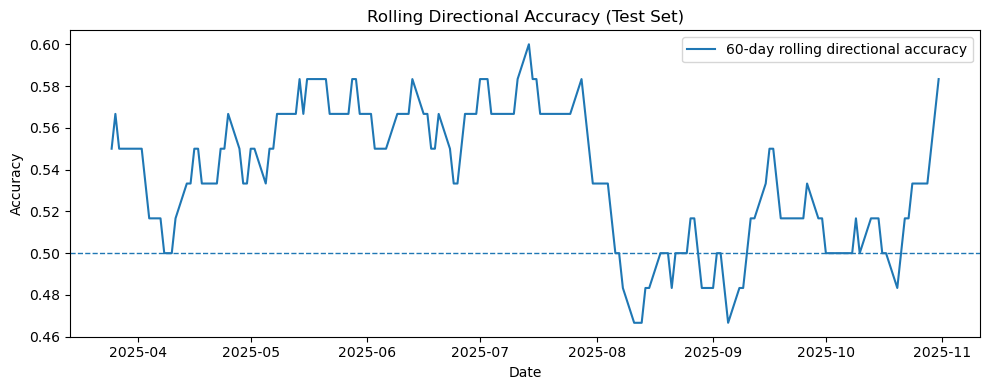

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def rolling_directional_accuracy(y_true, y_pred, window=60):
    correct = (np.sign(y_true) == np.sign(y_pred)).astype(int)
    return pd.Series(correct).rolling(window).mean()

# --- Recompute predictions on test for plotting ---
def collect_var_predictions(df_train, df_test, target_col, best_lag):
    history = df_train.copy()
    preds, trues, dates = [], [], []

    for i in range(len(df_test)):
        if len(history) < best_lag:
            history = pd.concat([history, df_test.iloc[[i]]])
            continue

        try:
            model = VAR(history).fit(best_lag)
            fc = model.forecast(history.values[-best_lag:], steps=1)[0]
            pred = fc[history.columns.get_loc(target_col)]
        except Exception:
            history = pd.concat([history, df_test.iloc[[i]]])
            continue

        preds.append(pred)
        trues.append(df_test.iloc[i][target_col])
        dates.append(df_test.index[i])

        history = pd.concat([history, df_test.iloc[[i]]])

    return pd.Series(trues, index=dates), pd.Series(preds, index=dates)

# --- collect data ---
cols = ["ret_1d"] + sel["selected_features"]
y_true, y_pred = collect_var_predictions(
    df_trva[cols],
    df_te[cols],
    target_col="ret_1d",
    best_lag=model.best_lag_,
)

roll_acc = rolling_directional_accuracy(y_true, y_pred, window=60)

# --- plot ---
plt.figure(figsize=(10, 4))
plt.plot(roll_acc, label="60-day rolling directional accuracy")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.title("Rolling Directional Accuracy (Test Set)")
plt.ylabel("Accuracy")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()


## Impulse Response Functions (IRFs)
This plot visualizes the dynamic response of oil returns to macroeconomic shocks within the estimated VAR. After fitting the final VAR on the combined training and validation data, I compute impulse response functions over a short horizon (e.g., 10 trading days). Each IRF traces the response of daily oil returns to a one-standard-deviation shock in one selected macro variable, holding all else constant.

I plot each macro shock separately to avoid imposing ordering assumptions and to keep the interpretation clear. I use non-orthogonalized IRFs to avoid reliance on Cholesky decomposition, which would otherwise make the results sensitive to variable ordering.

The resulting IRFs show that macro shocks have small, short-lived effects on oil returns that decay quickly toward zero. This behavior is consistent with market efficiency at daily horizons. While confidence bands are wide and often include zero, the sign and timing of responses remain economically plausible, supporting the interpretation that macro variables influence returns primarily through short-term expectations and risk channels.

VAR variable order: ['ret_1d', 'EXCAUSx', 'EXUSUKx', 'EXSZUSx', 'TB3SMFFM', 'TB6SMFFM']


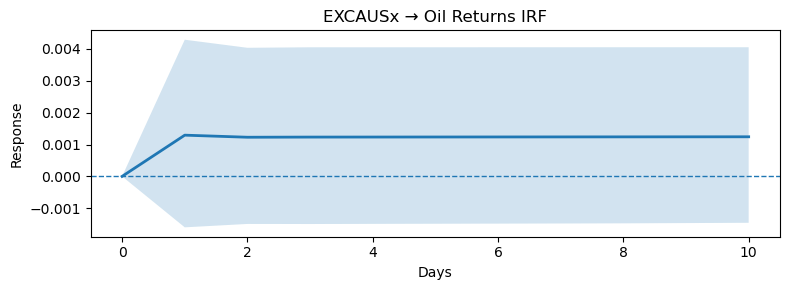

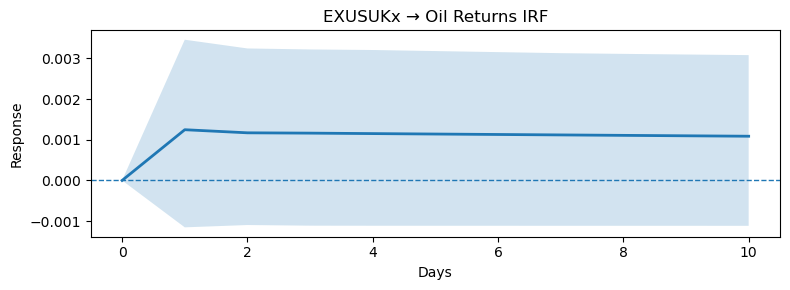

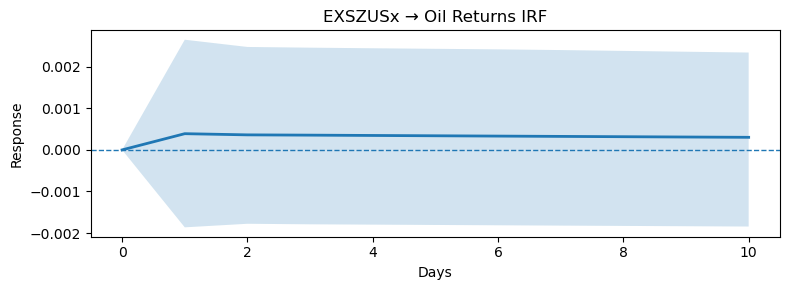

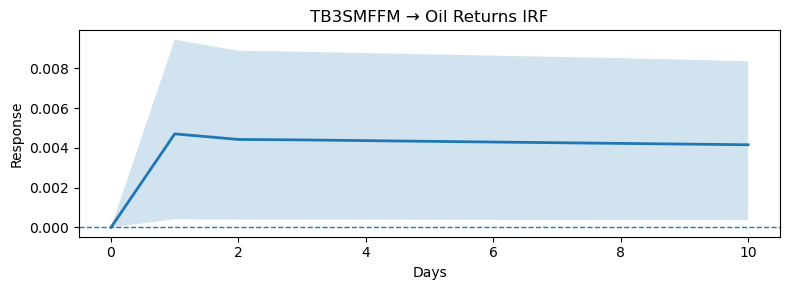

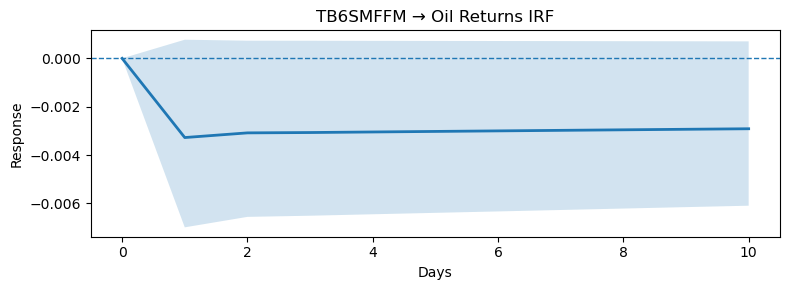

In [12]:
# ============================================================
# Impulse Response Functions (IRFs)
# Response: Oil returns
# Impulses: Selected macro variables
# ============================================================

import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# --- 1. Define columns used in the VAR ---
cols = ["ret_1d"] + sel["selected_features"]

# --- 2. Fit final VAR on train + validation data ---
var_model = VAR(df_trva[cols]).fit(model.best_lag_)

# Optional sanity check
print("VAR variable order:", var_model.names)

# --- 3. Compute impulse responses ---
horizon = 10  # 10 trading days
irf = var_model.irf(horizon)

# --- 4. Plot IRFs: one plot per macro shock ---
for shock in sel["selected_features"]:

    response_index = var_model.names.index("ret_1d")
    impulse_index = var_model.names.index(shock)

    irf_values = irf.irfs[:, response_index, impulse_index]

    # Monte Carlo confidence bands
    lower, upper = irf.errband_mc(orth=False)

    lower_vals = lower[:, response_index, impulse_index]
    upper_vals = upper[:, response_index, impulse_index]

    plt.figure(figsize=(8, 3))  # shorter
    plt.plot(irf_values, linewidth=2)
    plt.fill_between(
        range(len(irf_values)),
        lower_vals,
        upper_vals,
        alpha=0.2
    )
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.title(f"{shock} → Oil Returns IRF")
    plt.xlabel("Days")
    plt.ylabel("Response")
    plt.tight_layout()
    plt.show()


## Residual Autocorrelation (ACF)
This plot checks whether the VAR has successfully captured the linear temporal dependence in the data. I compute forecast residuals from the walk-forward test predictions and plot their autocorrelation function (ACF) over a fixed number of lags.

The goal here is diagnostic rather than predictive. If the VAR were misspecified or under-lagged, the residuals would exhibit significant autocorrelation, indicating remaining structure that the model failed to capture.

The residual ACF shows no systematic pattern and most autocorrelations lie within the confidence bands. This supports the choice of a lag-1 VAR, confirms that higher-order linear dependence has been absorbed, and suggests that remaining forecast errors are largely unpredictable noise rather than model misspecification.

<Figure size 800x400 with 0 Axes>

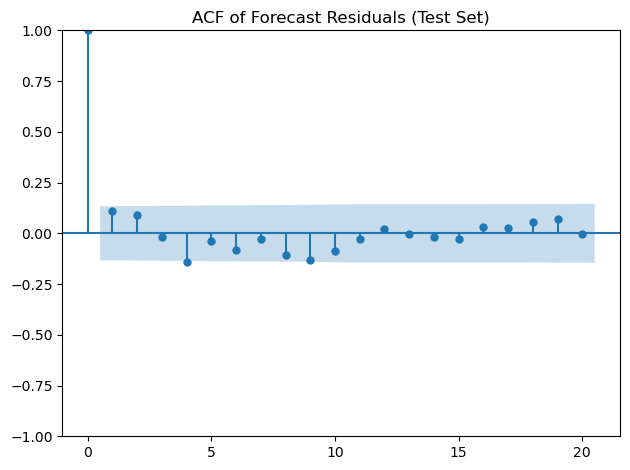

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = y_true - y_pred

plt.figure(figsize=(8, 4))
plot_acf(residuals, lags=20)
plt.title("ACF of Forecast Residuals (Test Set)")
plt.tight_layout()
plt.show()


## Forecast Error Distribution (Train vs Validation vs Test)

In this plot, I compare the distribution of forecast errors across the training, validation, and test sets. For the training set, I use in-sample one-step-ahead residuals from the fitted VAR. For the validation and test sets, I use true walk-forward forecast errors to preserve causal evaluation.

Overlaying the three distributions allows me to assess whether the model generalizes consistently or exhibits signs of overfitting or distribution shift. I normalize the histograms so that differences in sample size do not distort the comparison.

The distributions are tightly centered around zero and largely overlap across splits, indicating that the model is unbiased and stable out of sample. Slightly fatter tails in validation and test are expected given higher uncertainty out of sample. Overall, this plot provides strong evidence that the model’s behavior is consistent across data splits and not driven by overfitting.

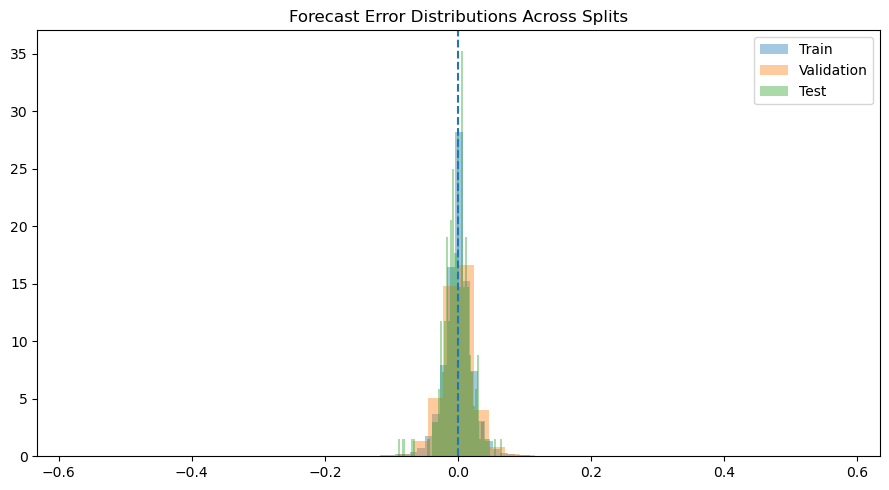

In [6]:
def collect_errors(df_train, df_eval, target_col, best_lag):
    history = df_train.copy()
    errors = []

    for i in range(len(df_eval)):
        if len(history) < best_lag:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        try:
            model = VAR(history).fit(best_lag)
            fc = model.forecast(history.values[-best_lag:], steps=1)[0]
            pred = fc[history.columns.get_loc(target_col)]
        except Exception:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        true = df_eval.iloc[i][target_col]
        errors.append(true - pred)
        history = pd.concat([history, df_eval.iloc[[i]]])

    return np.array(errors)

cols = ["ret_1d"] + sel["selected_features"]

err_tr = collect_errors(df_tr[cols], df_tr[cols], "ret_1d", model.best_lag_)
err_va = collect_errors(df_tr[cols], df_va[cols], "ret_1d", model.best_lag_)
err_te = collect_errors(df_trva[cols], df_te[cols], "ret_1d", model.best_lag_)


import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.hist(err_tr, bins=50, alpha=0.4, label="Train", density=True)
plt.hist(err_va, bins=50, alpha=0.4, label="Validation", density=True)
plt.hist(err_te, bins=50, alpha=0.4, label="Test", density=True)
plt.axvline(0, linestyle="--")
plt.title("Forecast Error Distributions Across Splits")
plt.legend()
plt.tight_layout()
plt.show()


## Rolling RMSE (Validation vs Test)

This plot examines how forecast difficulty evolves over time by computing a rolling RMSE on both the validation and test sets using walk-forward predictions. Instead of a static loss number, the rolling window reveals regime-dependent changes in forecast error magnitude.

I compute squared forecast errors at each step, apply a rolling window, and take the square root to obtain a time-varying RMSE. Plotting validation and test RMSE together allows for a direct comparison of out-of-sample behavior across splits.

The plot shows that validation and test RMSE remain on a similar scale throughout, with large spikes during periods of extreme volatility (e.g., crisis regimes). These spikes reflect genuine structural breaks rather than model failure. The absence of a systematic RMSE increase in the test set provides further evidence that the model generalizes well and does not overfit.

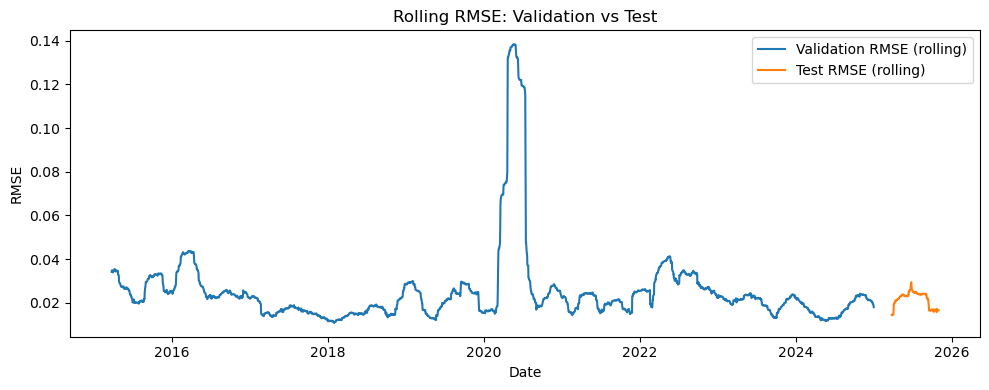

In [7]:
def rolling_rmse(y_true, y_pred, window=60):
    errors = y_true - y_pred
    return errors.rolling(window).apply(
        lambda x: np.sqrt(np.mean(x**2)), raw=True
    )

# collect predictions (reuse earlier function)
y_true_va, y_pred_va = collect_var_predictions(
    df_tr[cols], df_va[cols], "ret_1d", model.best_lag_
)
y_true_te, y_pred_te = collect_var_predictions(
    df_trva[cols], df_te[cols], "ret_1d", model.best_lag_
)

rmse_va = rolling_rmse(y_true_va, y_pred_va)
rmse_te = rolling_rmse(y_true_te, y_pred_te)


plt.figure(figsize=(10,4))
plt.plot(rmse_va, label="Validation RMSE (rolling)")
plt.plot(rmse_te, label="Test RMSE (rolling)")
plt.title("Rolling RMSE: Validation vs Test")
plt.ylabel("RMSE")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()


# Entire Code Block

In [17]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import pickle
import warnings

from abc import ABC, abstractmethod
from typing import List, Dict, Tuple, Optional

from statsmodels.tsa.api import VAR
from statsmodels.tools.sm_exceptions import ValueWarning


# ============================================================
# Silence statsmodels frequency warnings (SAFE)
# ============================================================
warnings.simplefilter("ignore", ValueWarning)


# ============================================================
# Base Forecast Model
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type

    @abstractmethod
    def fit(self, *args, **kwargs):
        pass

    @abstractmethod
    def evaluate(self, *args, **kwargs):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass


# ============================================================
# Metrics
# ============================================================
def rmse(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2))) if len(y) else np.nan

def mae(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.abs(y - yhat))) if len(y) else np.nan

def r2(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    if len(y) == 0:
        return np.nan
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.mean(np.sign(y) == np.sign(yhat))) if len(y) else np.nan


# ============================================================
# Data Helpers (LEAKAGE SAFE)
# ============================================================
def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    # keep only present features
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns in file (skipping): {missing}")
    return df[keep].copy()

def monthly_to_daily_strict(df: pd.DataFrame, daily_freq: str = "B") -> pd.DataFrame:
    """
    Month m data becomes available at month m+1 (anti-leakage).
    Forward-fill into DAILY grid:
      - daily_freq="B" business day (recommended with WTI trading days)
      - daily_freq="D" calendar day (if your class truly needs daily calendar freq)
    """
    df = df.copy()
    df.index = df.index + pd.offsets.MonthBegin(1)
    daily_idx = pd.date_range(df.index.min(), df.index.max(), freq=daily_freq)
    out = df.reindex(daily_idx).ffill()
    return out.dropna()

def load_price(path: Path) -> pd.Series:
    px = pd.read_csv(path, parse_dates=["Date"])
    # keep only non-null, sorted
    s = px.set_index("Date")["Price"].sort_index()
    return s

def daily_log_return(price: pd.Series) -> pd.Series:
    s = np.log(price.astype(float)).diff()
    return s.rename("ret_1d")


# ============================================================
# Build VAR Frame
# - IMPORTANT: do NOT "force" .freq onto an irregular index
# - If you need a strict daily index, we create one and reindex onto it
# ============================================================
def build_var_frame(
    macro_file: Path,
    price_file: Path,
    macro_features: list[str],
    train_end: str,
    val_end: str,
    daily_freq: str = "B",   # "B" business-day or "D" calendar-day
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    macro_m = load_macro_monthly(macro_file, macro_features)
    macro_d = monthly_to_daily_strict(macro_m, daily_freq=daily_freq)

    price = load_price(price_file)
    # align price to the same daily grid FIRST, then compute returns
    daily_idx = pd.date_range(
        start=max(macro_d.index.min(), price.index.min()),
        end=min(macro_d.index.max(), price.index.max()),
        freq=daily_freq,
    )
    price = price.reindex(daily_idx).ffill()  # no leakage: price is same-day value
    ret = daily_log_return(price)

    base = macro_d.reindex(daily_idx).join(ret, how="inner")

    # STRICT: never invent returns
    base = base.dropna(subset=["ret_1d"]).copy()
    base = base.sort_index()

    train_end = pd.Timestamp(train_end)
    val_end = pd.Timestamp(val_end)

    train = base.index <= train_end
    val = (base.index > train_end) & (base.index <= val_end)
    test = base.index > val_end

    return base.loc[train], base.loc[val], base.loc[test]


# ============================================================
# Walk-Forward VAR Evaluation (1-step ahead)
# - Fit VAR on expanding history
# - Forecast next step
# - Score target_col only
# ============================================================
def walk_forward_var_score(
    df_train: pd.DataFrame,
    df_eval: pd.DataFrame,
    target_col: str,
    best_lag: int,
    min_train_obs: int = 500,
) -> Dict:

    if target_col not in df_train.columns:
        raise ValueError(f"target_col={target_col} not in df_train columns")

    history = df_train.copy()
    y_true, y_pred = [], []

    for i in range(len(df_eval)):
        if len(history) < min_train_obs:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        try:
            model = VAR(history).fit(best_lag)
            fc = model.forecast(history.values[-best_lag:], steps=1)[0]
            pred = fc[history.columns.get_loc(target_col)]
        except Exception:
            history = pd.concat([history, df_eval.iloc[[i]]])
            continue

        y_true.append(df_eval.iloc[i][target_col])
        y_pred.append(pred)
        history = pd.concat([history, df_eval.iloc[[i]]])

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "best_lag": int(best_lag),
        "n_scored": int(len(y_true)),
        "rmse": rmse(y_true, y_pred),
        "mae": mae(y_true, y_pred),
        "r2": r2(y_true, y_pred),
        "directional_acc": directional_accuracy(y_true, y_pred),
    }


# ============================================================
# Greedy Forward Feature Selection (BIC + hard cap)
# - BIC penalizes size harder than AIC (better OOS behavior)
# - MAX_FEATURES prevents huge collinear systems
# ============================================================
def greedy_var_feature_select(
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    macro_candidates: list[str],
    target_col: str = "ret_1d",
    maxlags_grid: list[int] = [1, 2, 3, 5],
    max_features: int = 5,       # <-- key fix
    patience: int = 2,
) -> Dict:

    # only candidates that exist + have no all-NaN in train/val
    remaining = []
    for c in macro_candidates:
        if c in df_train.columns and c in df_val.columns:
            if (df_train[c].notna().any()) and (df_val[c].notna().any()):
                remaining.append(c)

    selected: list[str] = []
    history: list[dict] = []
    best_bic = np.inf
    no_improve = 0

    def bic_for_features(features: list[str]) -> Dict[str, float]:
        cols = [target_col] + features
        best = np.inf
        best_lag = None
        for lag in maxlags_grid:
            try:
                m = VAR(df_train[cols]).fit(lag)
                if np.isfinite(m.bic) and m.bic < best:
                    best = m.bic
                    best_lag = lag
            except Exception:
                continue
        return {"bic": best, "lag": best_lag if best_lag is not None else maxlags_grid[0]}

    # --- First feature (best single feature by BIC)
    best_feat = None
    best_res = None
    for f in remaining:
        res = bic_for_features([f])
        if np.isfinite(res["bic"]) and res["bic"] < best_bic:
            best_bic = res["bic"]
            best_feat = f
            best_res = res

    if best_feat is None:
        return {
            "selected_features": [],
            "best_val_bic": np.nan,
            "history": history,
            "message": "No feature produced a valid VAR fit. Try smaller maxlags_grid or fewer columns.",
        }

    selected.append(best_feat)
    remaining.remove(best_feat)
    history.append({"added": best_feat, "score": best_res, "selected_now": selected.copy()})

    # --- Forward selection (stop at max_features)
    while remaining and len(selected) < max_features:
        round_best_feat = None
        round_best_res = None
        round_best_bic = best_bic

        for f in remaining:
            res = bic_for_features(selected + [f])
            if np.isfinite(res["bic"]) and res["bic"] < round_best_bic:
                round_best_bic = res["bic"]
                round_best_feat = f
                round_best_res = res

        if round_best_feat is None:
            no_improve += 1
            if no_improve >= patience:
                break
            continue

        # accept improvement
        best_bic = round_best_bic
        selected.append(round_best_feat)
        remaining.remove(round_best_feat)
        history.append({"added": round_best_feat, "score": round_best_res, "selected_now": selected.copy()})
        no_improve = 0

    return {
        "selected_features": selected,
        "best_val_bic": float(best_bic) if np.isfinite(best_bic) else np.nan,
        "history": history,
    }


# ============================================================
# Final VAR Model
# - pick lag by BIC on train+val
# - walk-forward on test
# ============================================================
class VARForecastModel(BaseForecastModel):
    def __init__(self, maxlags_grid: list[int] = [1, 2, 3, 5], target_col: str = "ret_1d"):
        super().__init__("regression")
        self.maxlags_grid = maxlags_grid
        self.target_col = target_col
        self.selected_features_: list[str] = []
        self.best_lag_: Optional[int] = None

    def fit(self, df: pd.DataFrame, selected_features: list[str]):
        self.selected_features_ = selected_features
        cols = [self.target_col] + selected_features

        best_bic, best_lag = np.inf, None
        for lag in self.maxlags_grid:
            try:
                m = VAR(df[cols]).fit(lag)
                if np.isfinite(m.bic) and m.bic < best_bic:
                    best_bic, best_lag = m.bic, lag
            except Exception:
                continue

        self.best_lag_ = int(best_lag) if best_lag is not None else int(self.maxlags_grid[0])
        return self

    def evaluate(self, df_train: pd.DataFrame, df_test: pd.DataFrame) -> Dict:
        cols = [self.target_col] + self.selected_features_
        return walk_forward_var_score(
            df_train=df_train[cols],
            df_eval=df_test[cols],
            target_col=self.target_col,
            best_lag=self.best_lag_ if self.best_lag_ is not None else self.maxlags_grid[0],
        )

    def save(self, path: str):
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, path: str):
        with open(path, "rb") as f:
            self.__dict__.update(pickle.load(f))


# ============================================================
# RUN
# ============================================================
if __name__ == "__main__":

    MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
    PRICE_FILE = Path("Price/Price.csv")

    FEATURES = [
        "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
        "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
        "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
        "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
        "PPICMM","UMCSENTx"
    ]

    # If your class truly requires calendar daily frequency, set daily_freq="D"
    # Otherwise keep "B" for trading-day alignment.
    DAILY_FREQ = "B"

    df_tr, df_va, df_te = build_var_frame(
        MACRO_FILE,
        PRICE_FILE,
        FEATURES,
        train_end="2014-12-31",
        val_end="2024-12-31",
        daily_freq=DAILY_FREQ,
    )

    print("Shapes:", df_tr.shape, df_va.shape, df_te.shape)

    sel = greedy_var_feature_select(
        df_train=df_tr,
        df_val=df_va,
        macro_candidates=FEATURES,
        target_col="ret_1d",
        maxlags_grid=[1, 2, 3, 5],
        max_features=5,   # <-- key fix
        patience=2,
    )

    print("Selected:", sel["selected_features"])
    print("Best val BIC:", sel.get("best_val_bic"))
    if sel.get("history"):
        print("Selection last step:", sel["history"][-1])

    df_trva = pd.concat([df_tr, df_va])

    model = VARForecastModel(maxlags_grid=[1, 2, 3, 5], target_col="ret_1d")
    model.fit(df_trva, sel["selected_features"])

    test_metrics = model.evaluate(df_trva, df_te)
    print("Final best lag:", model.best_lag_)
    print("Test metrics:", test_metrics)

    model.save("var_wti_final.pkl")


Shapes: (8284, 32) (2609, 32) (218, 32)
Selected: ['EXCAUSx', 'EXUSUKx', 'EXSZUSx', 'TB3SMFFM', 'TB6SMFFM']
Best val BIC: -52.88196495747408
Selection last step: {'added': 'TB6SMFFM', 'score': {'bic': np.float64(-52.88196495747408), 'lag': 1}, 'selected_now': ['EXCAUSx', 'EXUSUKx', 'EXSZUSx', 'TB3SMFFM', 'TB6SMFFM']}
Final best lag: 1
Test metrics: {'best_lag': 1, 'n_scored': 218, 'rmse': 0.020516321066247716, 'mae': 0.014967130987017642, 'r2': -0.012796168256945517, 'directional_acc': 0.5412844036697247}
